---
title: Daraz.pk Product Performance Analysis
author: Danyal Malik, Murtaza Ur Rehman, Daanish Uddin Khan, Noor Ul Hassan, Raiyaan Junaid
date: '2023-12-10'
categories:
  - code
format:
  html:
    code-fold: true
    code-tools: true
---

# Dissecting the Performance of E-Commerce Products using Data Science

In this analysis, we determine what a seller must focus in order to achieve the best product rating using both Causal Inference as well as Machine Learning methods. Furthermore, we also dissect how trust in products can affect the performance of a product.

Specifically, we will be focussing on the Pakistani E-Commerce website, Daraz.pk. The dataset used in this analysis was scraped directly from the website and contains information about many different aspects of the listing.

## Causal Inference

We will start off by using Causal Inference to determine the effect of certain features on the performance of a product (measured by its product rating).

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Sample Data

In [3]:
data = pd.read_csv('final_dataset.csv')

data = data.drop(['Unnamed: 0'], axis=1)

data.head()

,Name,Category,Daraz Mall,url,Original Price,Discounted Price,Rating,Reviews,Seller,Seller Rating,Chat Response Time,Warranty,Delivery Charges,Brand,Answered Questions,Discount
0,Daal Moong/Mong - 1Kg (Premium Grains) - Zeest,"Groceries, Canned, Dry & Packaged Foods, Grain...",True,https://www.daraz.pk/products/daal-moongmong-1...,395,319,4.5,22,Zeest,0.92,0.88,0.0,158.0,Zeest,0.0,True
1,Daal Masoor/Masur - 1Kg (Premium Grains) - Zeest,"Groceries, Canned, Dry & Packaged Foods, Grain...",True,https://www.daraz.pk/products/daal-masoormasur...,479,399,4.4,14,Zeest,0.92,0.88,0.0,158.0,Zeest,0.0,True
2,Chia Seeds 500 g (Organic and Original 500 gra...,"Groceries, Canned, Dry & Packaged Foods, Grain...",False,https://www.daraz.pk/products/500-500-i4317113...,1200,1099,5.0,10,Nuts & Snax,0.89,1.00,0.0,0.0,No Brand,0.0,True
3,Moisture Absorber Dehumidifier Desicant 200 gr...,"Groceries, Laundry & Household, AirCare, Dehum...",False,https://www.daraz.pk/products/moisture-absorbe...,1000,599,5.0,2,Super Shop..,0.92,0.98,0.0,0.0,No Brand,0.0,True
4,Barg e Sanober Powder (50GM),"Groceries, Canned, Dry & Packaged Foods, Grain...",False,https://www.daraz.pk/products/50-i432512130-s2...,600,500,5.0,1,Super pansar store,0.86,0.76,0.0,119.0,Generic,0.0,True


### Heatmap of Correlation Matrix

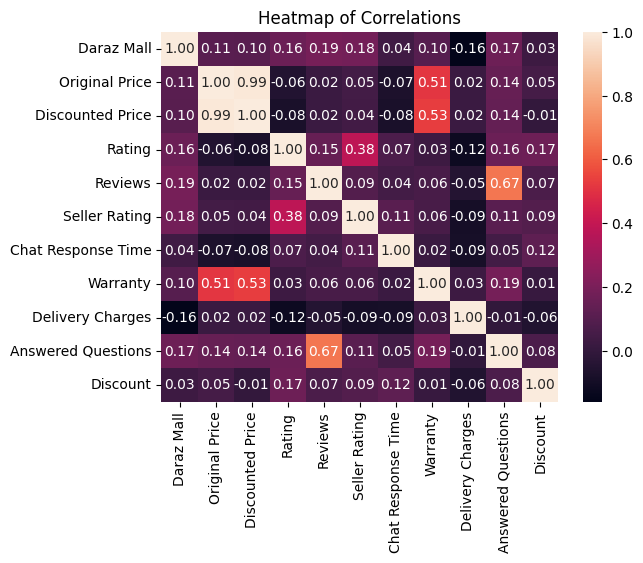

In [4]:
# excluding string columns

correlation = data.select_dtypes(exclude=['object']).corr()

sns.heatmap(correlation, annot=True, cmap='rocket', fmt=".2f")

plt.title('Heatmap of Correlations')
plt.show()

From the correlation heatmap, we want to investigate the level of correlations between the 'Rating' feature vs. other features to see what other features have a positive or negative affect on 'Rating', and so we can begin to answer our first research question: WHAT FEATURE VARIABLES SHOULD SELLERS OPTIMISE ON THEIR STOREFRONTS FOR MAXIMUM PRODUCT RATINGS?

from the heat heatmap we can see:
1. Rating has the highest positive correlation of 0.38 with 'Seller Rating'. 
2. Rating has the second highest positive correlation of 0.17 with 'Discount'.
3. Rating has the third highest positive correlation with of 0.16 with 'Answered Questions' and 'Daraz Mall'.
4. Rating has a somewhat noticeable negative correlation of -0.12 with 'Delivery Charges'.

Let's break this down a bit:
1. Since 'Rating' has the highest positive correlation with 'Seller Rating', it would be worth noting what makes for a higher positive 'Seller Rating'. Looking at 'Seller Rating's' correlations, we can see that it is positively dependant on 'Daraz Mall', 'Discount', 'Chat Response Time' and 'Answered Questions'. From these observations, it wouldnt be unreasonable to assume that if we can optimize chat response time, number of questions answered and were registered on Daraz Mall, that our product rating should go up in the long-term. What this means for total sales over a given period of time is still out for discussion, but having a higher rated product is an effective and immediate way to influence buyers' perceptions about your product, positively, and therefore garner trust and higher sales.

2. 'Rating' is showing a tendency to go up with 'Discount', which makes sense in the context of a buyer-seller relationship online. Customers are more likely to harbor positive sentiment for a product they got for less compared to if a similar product is offered for more by another seller. 

4. From the negative correlation with 'Delivery Charges', we can see that people may not be happy with paying extra for delivery, which gets translated into lower product ratings. 

### Conditional Average Treatment Effect

In [5]:
def CATE(treatment_col, covariate_cols):
    outcome_col = 'Rating'

    if treatment_col == "Discount":
        ate = data[outcome_col][data[treatment_col] == True].mean() - data[outcome_col][data[treatment_col] == False].mean()
    else:
        ate = data[outcome_col][data[treatment_col] > data[treatment_col].mean()].mean() - data[outcome_col][data[treatment_col] < data[treatment_col].mean()].mean()
    print("ATE without conditioning between {} and Rating: {:.4f}\n".format(treatment_col, ate))

    for covariate in covariate_cols:
        if covariate != 'Discount':
            ate_conditioned1 = data[outcome_col][(data[treatment_col] > data[treatment_col].mean()) & (data[covariate] < data[covariate].mean())].mean() - data[outcome_col][(data[treatment_col] < data[treatment_col].mean()) & (data[covariate] < data[covariate].mean())].mean()
            print("...conditioned on {} for less than mean: {:.4f}".format(covariate, ate_conditioned1))

            ate_conditioned2 = data[outcome_col][(data[treatment_col] > data[treatment_col].mean()) & (data[covariate] > data[covariate].mean())].mean() - data[outcome_col][(data[treatment_col] < data[treatment_col].mean()) & (data[covariate] > data[covariate].mean())].mean()
            print("...conditioned on {} for greater than mean: {:.4f}".format(covariate, ate_conditioned2))

            # finding weighted cate
            ate_conditioned = ate_conditioned1 * (data[covariate] < data[covariate].mean()).sum() / data.shape[0] + ate_conditioned2 * (data[covariate] > data[covariate].mean()).sum() / data.shape[0]

            print("...overall cate: {:.4f}\n".format(ate_conditioned))

        if covariate == 'Discount':
            ate_conditioned1 = data[outcome_col][(data[treatment_col] > data[treatment_col].mean()) & (data[covariate] == True)].mean() - data[outcome_col][(data[treatment_col] < data[treatment_col].mean()) & (data[covariate] == True)].mean()
            print("...conditioned on {} for True: {:.4f}".format(covariate, ate_conditioned1))

            ate_conditioned2 = data[outcome_col][(data[treatment_col] > data[treatment_col].mean()) & (data[covariate] == False)].mean() - data[outcome_col][(data[treatment_col] < data[treatment_col].mean()) & (data[covariate] == False)].mean()
            print("...conditioned on {} for False: {:.4f}".format(covariate, ate_conditioned2))

            ate_conditioned = ate_conditioned1 * (data[covariate] == True).sum() / data.shape[0] + ate_conditioned2 * (data[covariate] == False).sum() / data.shape[0]

            print("...overall cate: {:.4f}\n".format(ate_conditioned))


In [6]:
CATE("Discount", ['Answered Questions', 'Delivery Charges', 'Seller Rating'])

ATE without conditioning between Discount and Rating: 0.7848

...conditioned on Answered Questions for less than mean: 0.7116
...conditioned on Answered Questions for greater than mean: -0.0132
...overall cate: 0.5710

...conditioned on Delivery Charges for less than mean: 0.7386
...conditioned on Delivery Charges for greater than mean: 0.8802
...overall cate: 0.7422

...conditioned on Seller Rating for less than mean: 0.1985
...conditioned on Seller Rating for greater than mean: 0.6211
...overall cate: 0.4097



From the results, we can see that the overall treatment effect of 'Discount' on 'Rating' change as we apply different conditioning. 

According to our correlation heatmap, 'Seller Rating' had the highest positive correlation, and when conditioned on here, we see the overall CATE of 'Discount' go down to 0.4097. We interpret this as the CATE closest to the true ATE of 'Discount' on 'Rating' if conditioned on one variable.

In [7]:
CATE("Answered Questions", ['Discount', 'Delivery Charges', 'Seller Rating'])


ATE without conditioning between Answered Questions and Rating: 1.4900

...conditioned on Discount for True: 1.3023
...conditioned on Discount for False: 2.0271
...overall cate: 1.4731

...conditioned on Delivery Charges for less than mean: 1.3260
...conditioned on Delivery Charges for greater than mean: 1.6791
...overall cate: 1.3738

...conditioned on Seller Rating for less than mean: 1.6762
...conditioned on Seller Rating for greater than mean: 0.8584
...overall cate: 0.9741



Similarly, conditioning on 'Seller Rating' here gives us an overall CATE of 0.9741, which we interpret as the CATE closer to the true ATE of 'Answered Questions' in the absence of the confounder 'Seller Rating'. 

In [8]:
CATE("Delivery Charges", ['Discount', 'Answered Questions', 'Seller Rating'])

ATE without conditioning between Delivery Charges and Rating: -0.4469

...conditioned on Discount for True: -0.3756
...conditioned on Discount for False: -0.5172
...overall cate: -0.4090

...conditioned on Answered Questions for less than mean: -0.4190
...conditioned on Answered Questions for greater than mean: -0.0659
...overall cate: -0.3505

...conditioned on Seller Rating for less than mean: -0.5869
...conditioned on Seller Rating for greater than mean: -0.3306
...overall cate: -0.3581



Here, since conditioning on 'Answered Questions' results in the smallest, negative treatment effect, we interpret this as the CATE closer to the true ATE of 'Delivery Charges' on 'Rating'.

In [9]:
CATE("Seller Rating", ['Discount', 'Answered Questions', 'Delivery Charges'])

ATE without conditioning between Seller Rating and Rating: 1.0616

...conditioned on Discount for True: 1.1160
...conditioned on Discount for False: 0.6934
...overall cate: 1.0164

...conditioned on Answered Questions for less than mean: 0.9920
...conditioned on Answered Questions for greater than mean: 0.1742
...overall cate: 0.8334

...conditioned on Delivery Charges for less than mean: 0.9433
...conditioned on Delivery Charges for greater than mean: 1.1996
...overall cate: 0.9794



### Plotting the Ratings

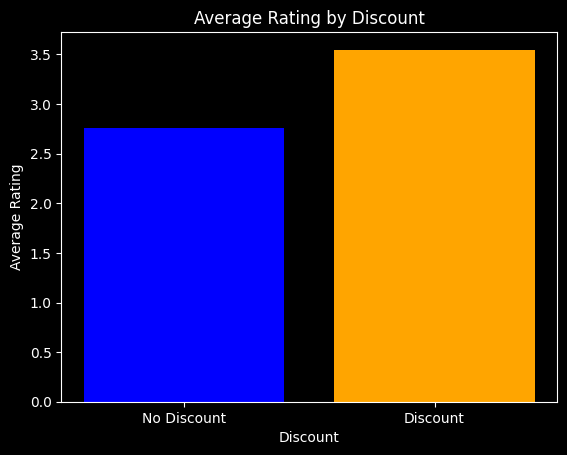

In [12]:
data['Discount'] = data['Discount'].astype(int)

plt.style.use('dark_background')

grouped_data = data.groupby('Discount')['Rating'].mean().reset_index()

plt.bar(grouped_data['Discount'], grouped_data['Rating'], color=['blue', 'orange'])
plt.xlabel('Discount')
plt.ylabel('Average Rating')
plt.title('Average Rating by Discount')
plt.xticks(grouped_data['Discount'], ['No Discount', 'Discount'])
plt.show()
# Make sure to encode the 'Discount' variable as 1 for True and 0 for False
data['Discount'] = data['Discount'].astype(int)

Answered Questions and Seller Rating are the two features that have the highest positive correlation with Rating. This means that if a seller wants to increase the rating of their product, they should focus on increasing the number of questions they answer and increasing their seller rating.

Moreover, Delivery Charges have a negative correlation and ATE on Rating. This indicates that sellers should come up with innovative ways to reduce delivery charges on their customers or come up with novel ways of absorbing delivery cost so that their customers either:
 
A) do not have to pay high delivery charges
B) perceive they are not paying delivery charges (this can be done by 'free delivery' tactics wherein the delivery cost is integrated into the product cost)

## Machine Learning

Our primary objective here is to figure out what a seller can focus on to improve the product rating. This problem, in machine learning, can be represented as feature selection.

Another challenge we had in causal inference was that our data (much of it), was real-valued/continuous, which means that we simply had to divide it into different classes to condition on it (< mean, > mean). With ML methods, we can use the data as is, and let the model figure out the best way to use it.

### Linear Regression

In [178]:
# Separating Features and Target Variables

# Find numeric columns

# !pip install scikit-learn

numeric_columns = [col for col in data.columns if data[col].dtype != 'object']

X = data[numeric_columns]

X = X.dropna()

y = X['Rating']

X = X.drop(['Rating'], axis=1)

# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Linear Regression

from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()

linear_regression.fit(X_train, y_train)

y_pred = linear_regression.predict(X_test)

# find rmse and mae
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt

linear_regression_rmse = sqrt(mean_squared_error(y_pred, y_test))
linear_regression_mae = mean_absolute_error(y_pred, y_test)

print('RMSE for Linear Regression (Test): ', linear_regression_rmse)
print('MAE for Linear Regression (Test): ', linear_regression_mae)

RMSE for Linear Regression (Test):  1.7273061258086269
MAE for Linear Regression (Test):  1.188439527213344


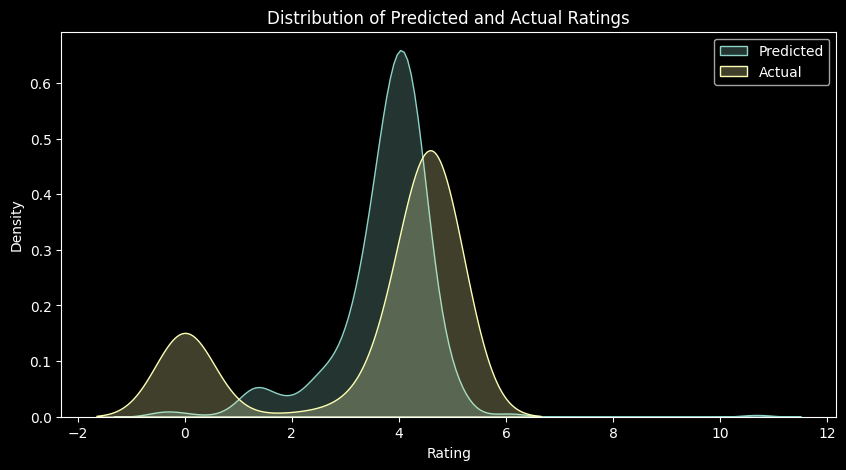

In [179]:
# plotting distribution of y_test and y_pred

plt.figure(figsize=(10, 5))
sns.kdeplot(y_pred, label='Predicted', fill=True)
sns.kdeplot(y_test, label='Actual', fill=True)
plt.title('Distribution of Predicted and Actual Ratings')
plt.legend()
plt.show()

We can see that our MAE is very large, i.e. ~1.1 (as our rating scale is out of 5), from which we can judge that we need a better model before we can check which features are important. For example, we can try using a Random Forest Regressor to see if we can get a better MAE.

### Random Forest Regressor

In [ ]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor()

random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)

# find rmse and mae

random_forest_rmse = sqrt(mean_squared_error(y_pred, y_test))
random_forest_mae = mean_absolute_error(y_pred, y_test)

print('RMSE for Random Forest Regressor (Test): ', random_forest_rmse)
print('MAE for Random Forest Regressor (Test): ', random_forest_mae)

RMSE for Random Forest Regressor (Test):  0.3225117788462206
MAE for Random Forest Regressor (Test):  0.1736906318082792


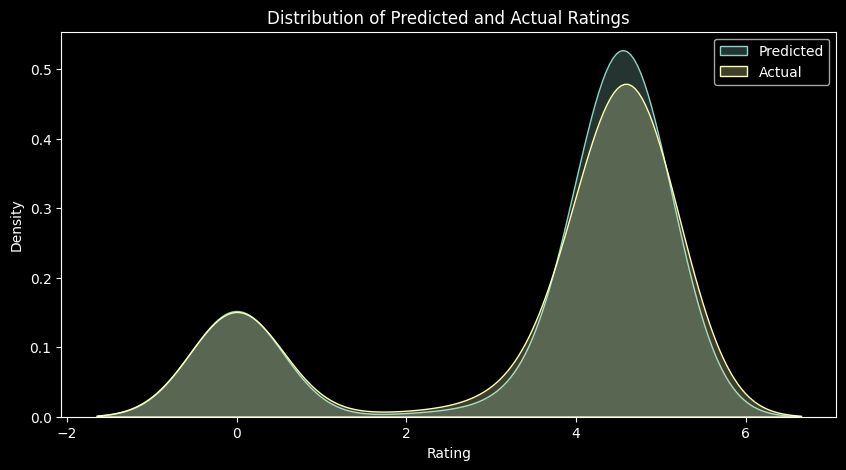

In [181]:
# plot distribution of y_test and y_pred

plt.figure(figsize=(10, 5))
sns.kdeplot(y_pred, label='Predicted', fill=True)
sns.kdeplot(y_test, label='Actual', fill=True)

plt.title('Distribution of Predicted and Actual Ratings')

plt.legend()

plt.show()

### Random Forest Regressor - Feature Importance

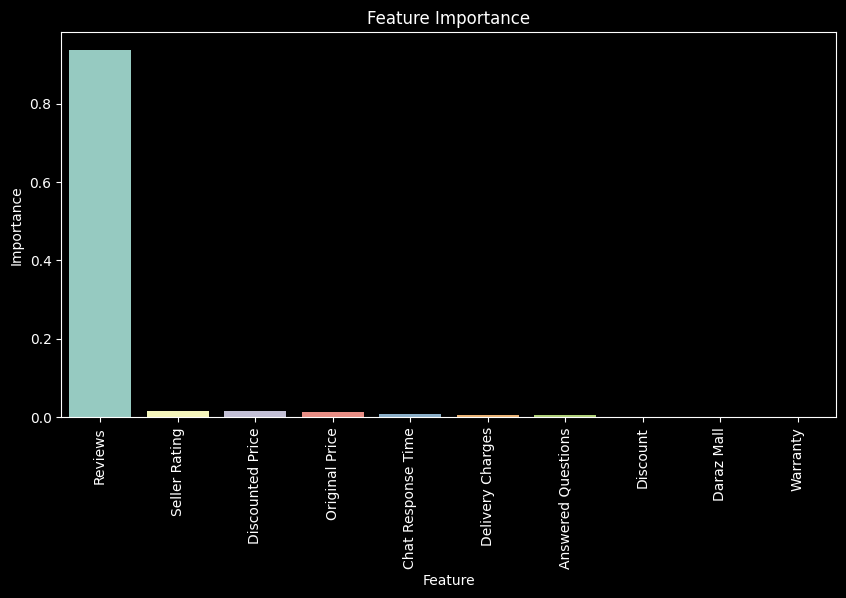

In [182]:
# Feature Importance

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': random_forest.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance['Feature'], y=feature_importance['Importance'])
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()

We can see that the number of reviews is a very good predictor for rating. However, this makes sense as more popular products are more likely to have more reviews. However, such a feature cannot be controlled by the seller, and therefore, we will not consider it in our analysis. We should also remove any other features that are not in control of the seller. So, in the next step, we will remove the following features:

1. 'Reviews'
2. 'Original Price'
3. 'Discounted Price'

The reason we are removing price data is because higher priced products tend to be higher quality, but the seller cannot control the price of the product (to a large extent, other than lowering their own profit margins). Therefore, we will remove price data from our analysis. Instead, we can update the feature 'Discount' to be the percentage of discount offered by the seller.

Features to add:

1. 'Discount' (percentage)
2. Brand

The brand will now simply represent whether or not the product had a brand displayed with it. This will help us determine effect on rating. Furthermore, paired with daraz mall, we can see whether features associated with trust have a positive effect on rating.

In [183]:
# Update discount to represent percentage (0-1)

X["Discount"] = ((X["Original Price"] - X["Discounted Price"]) / X["Original Price"])
X["Brand"] = data["Brand"] != "No Brand"

# Remove reviews, original price and discount price

X = X.drop(['Reviews', 'Original Price', 'Discounted Price'], axis=1)

X.head()

,Daraz Mall,Seller Rating,Chat Response Time,Warranty,Delivery Charges,Answered Questions,Discount,Brand
0,True,0.92,0.88,0.0,158.0,0.0,0.192405,True
1,True,0.92,0.88,0.0,158.0,0.0,0.167015,True
2,False,0.89,1.00,0.0,0.0,0.0,0.084167,False
3,False,0.92,0.98,0.0,0.0,0.0,0.401000,False
4,False,0.86,0.76,0.0,119.0,0.0,0.166667,True


In [184]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(random_state=1)

# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)

# find rmse

random_forest_rmse = sqrt(mean_squared_error(y_pred, y_test))
random_forest_mae = mean_absolute_error(y_pred, y_test)

print('RMSE for Random Forest Regressor (Test): ', random_forest_rmse)
print('MAE for Random Forest Regressor (Test): ', random_forest_mae)

RMSE for Random Forest Regressor (Test):  1.1520124954711073
MAE for Random Forest Regressor (Test):  0.6448624686660924


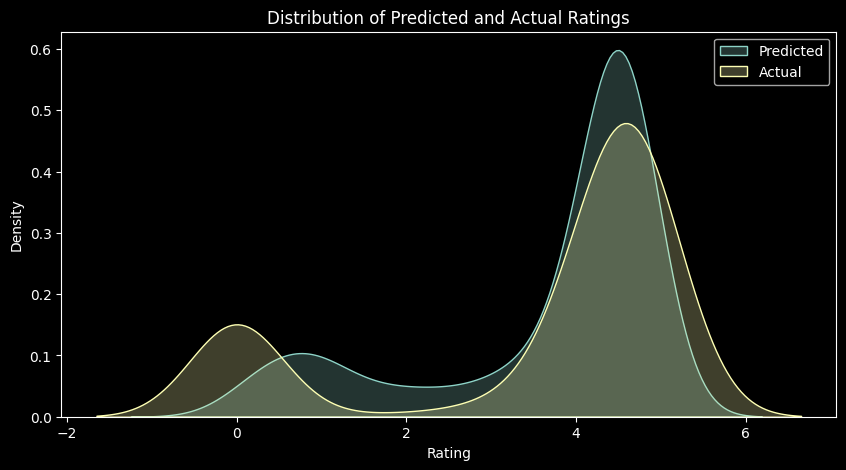

In [185]:
# plot distribution of y_test and y_pred

plt.figure(figsize=(10, 5))

sns.kdeplot(y_pred, label='Predicted', fill=True)
sns.kdeplot(y_test, label='Actual', fill=True)

plt.title('Distribution of Predicted and Actual Ratings')

plt.legend()

plt.show()

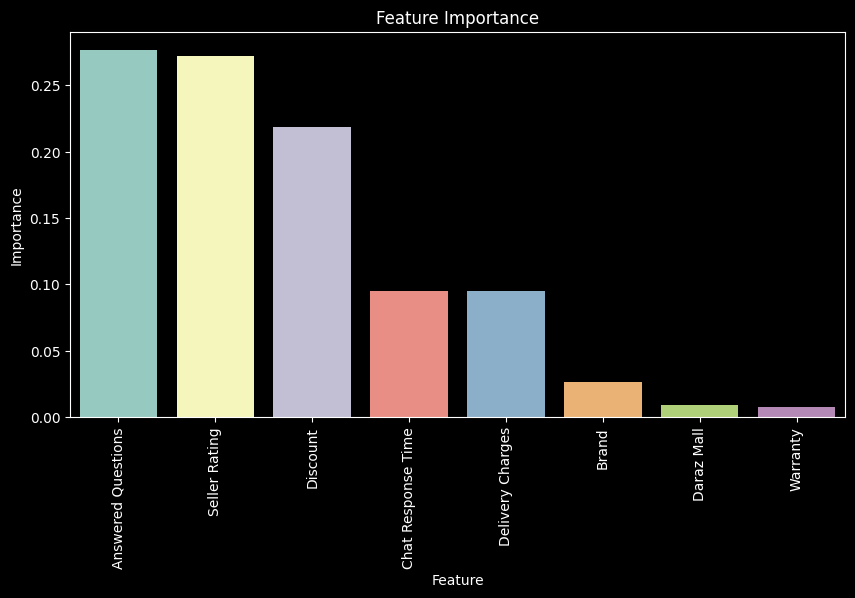

In [186]:
# Feature Importance

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': random_forest.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(x=feature_importance['Feature'], y=feature_importance['Importance'])

plt.xticks(rotation=90)

plt.title('Feature Importance')

plt.show()

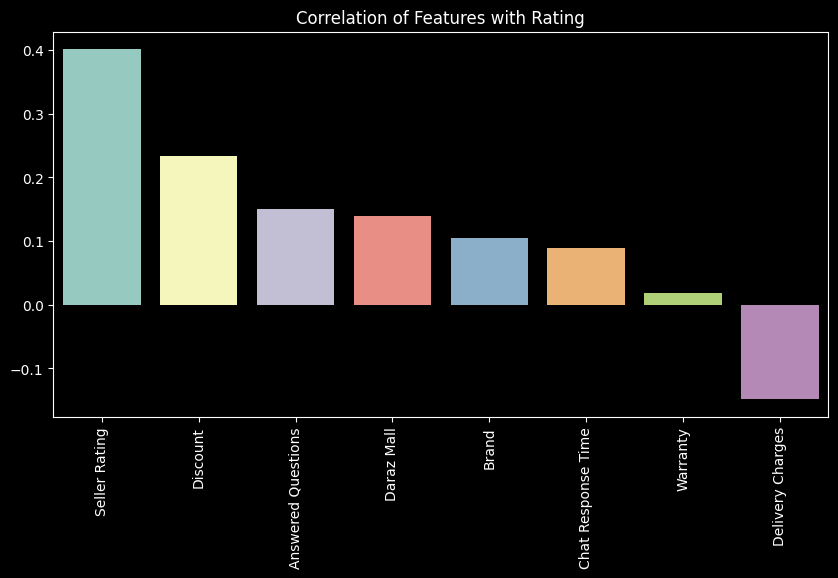

In [187]:
# Correlation of each feature in X with rating Y

correlation = X.corrwith(y)

correlation = correlation.sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(x=correlation.index, y=correlation.values)

plt.xticks(rotation=90)

plt.title('Correlation of Features with Rating')

plt.show()


From this, we can see that answered questions, seller rating and discount have a high impact on the rating, while delivery charges have a negative impact on the rating. This is in line with our causal inference analysis. We can also see that both brand and daraz mall have a positive impact on the rating, which means that although trust is important, it is not as important as the other features. So, for a seller to improve their product's rating, they should focus on the following:

1. Answering questions
2. Seller rating
3. Discount

They should be active in answering questions on the platform, and should try to get a higher seller rating. Furthermore, they should offer discounts on their products to improve their rating.

### Confirming our findings with XGBoost Regressor

RMSE for XGBoost (Test):  1.1998391451174661
MAE for XGBoost (Test):  0.6501739651214307


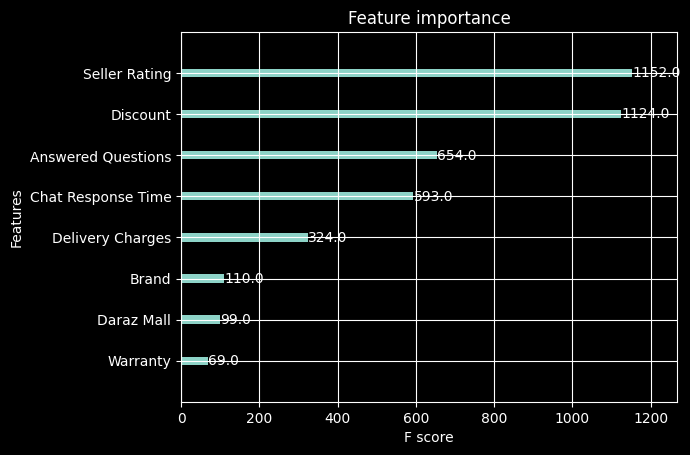

In [188]:
# !pip install xgboost
import xgboost as xgb
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Fit the model
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# Evaluate

y_pred = model.predict(X_test)

# find rmse and mae

xgboost_rmse = sqrt(mean_squared_error(y_pred, y_test))
xgboost_mae = mean_absolute_error(y_pred, y_test)

print('RMSE for XGBoost (Test): ', xgboost_rmse)
print('MAE for XGBoost (Test): ', xgboost_mae)

# Plot feature importances
plot_importance(model)
plt.show()